# Aula Prática 5: Transformada de Hadamard e Sistemas CDMA

1 ) A transformada de Hadamard é utilizada na geração de códigos em sistemas CDMA (code division multiple access), base do 3G. A multiplexação nos sistemas CDMA é realizada associando um código a cada usuário, sendo que cada código é ortogonal aos demais. Para avaliar o impacto da transformada de Hadamard nos sistemas CDMA, faça o que se pede nos itens abaixo.

### (a) Geração de Sequências e Codificação

Considere um sistema CDMA com 3 usuários. Para cada usuário, gere as sequências $m_1[n] \in \{-1,1\}$, $m_2[n] \in \{-1,1\}$ e $m_3[n] \in \{-1,1\}$ de comprimento 8. Utilizando um código de Hadamard de comprimento 8, codifique os sinais $m_1[n]$, $m_2[n]$ e $m_3[n]$. Mostre o gráfico do sinal original de cada usuário, do seu respectivo código e do sinal codificado. Além disso, mostre o espectro dos sinais originais e codificados e comente o impacto da codificação no espectro do sinal.

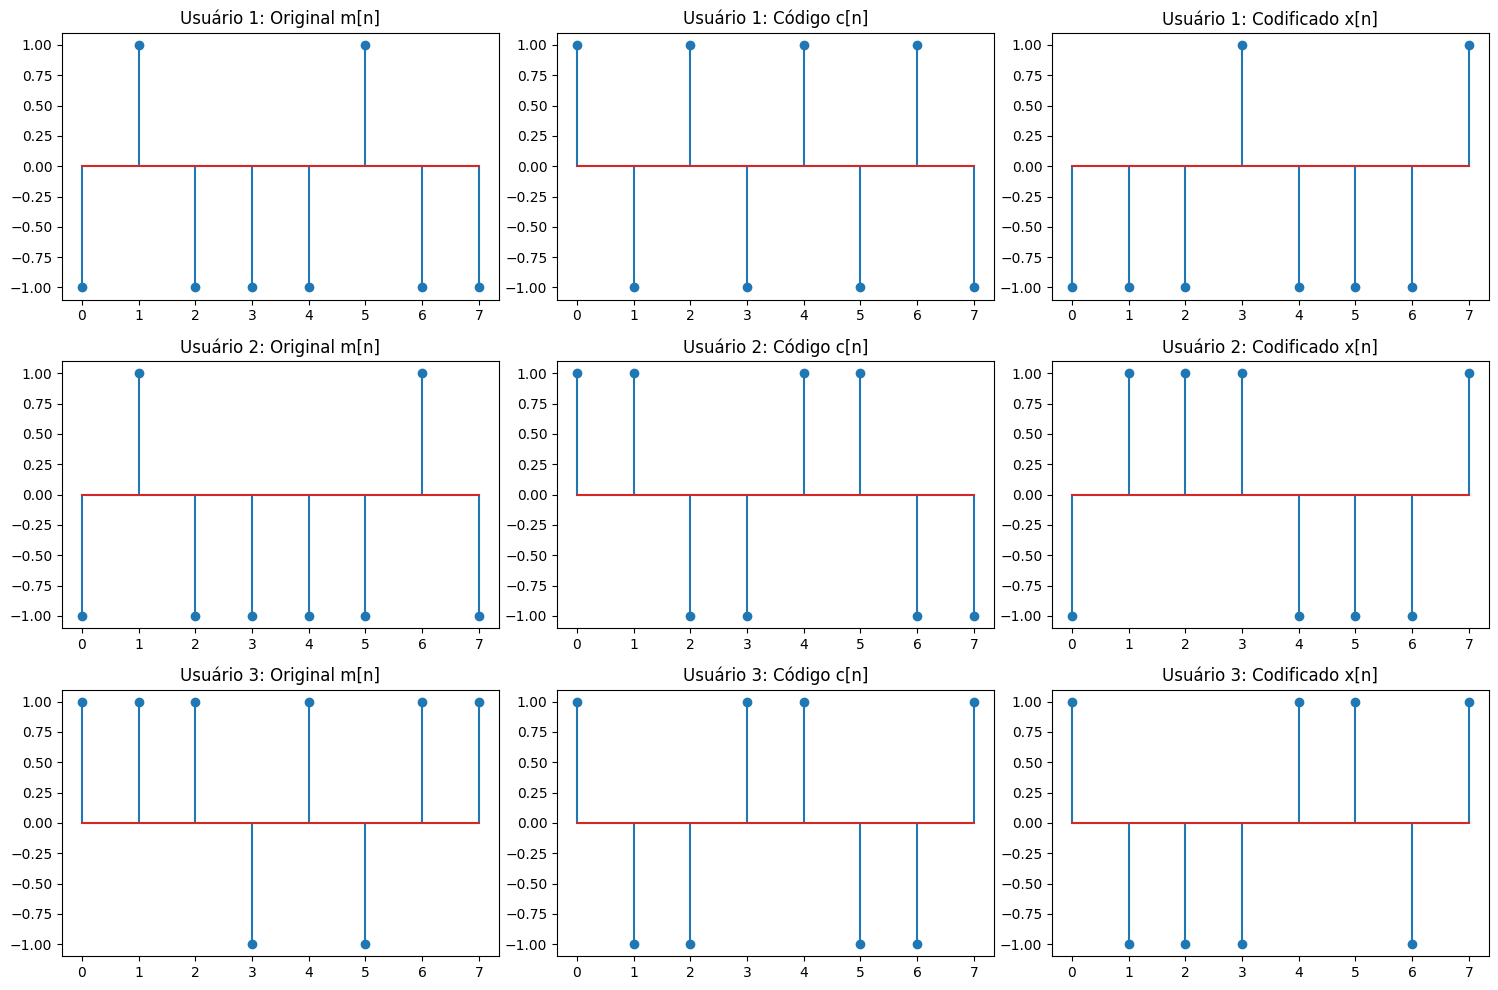

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard
from scipy.fft import fft, fftshift

def plot_spectrum(signal, title, fs=1):
    n = len(signal)
    f = np.linspace(-fs/2, fs/2, n)
    spectrum = fftshift(np.abs(fft(signal, n)))
    plt.plot(f, spectrum)
    plt.title(title)
    plt.grid(True)

# (a) Configurações iniciais
L = 8 # Comprimento
C = hadamard(L)

# Gerar sequências m[n] aleatórias {-1, 1}
np.random.seed(42)
m1 = np.random.choice([-1, 1], L)
m2 = np.random.choice([-1, 1], L)
m3 = np.random.choice([-1, 1], L)

# Selecionar códigos de Hadamard (linhas da matriz)
c1, c2, c3 = C[1], C[2], C[3]

# Codificação (Espalhamento)
x1 = m1 * c1
x2 = m2 * c2
x3 = m3 * c3

# Visualização
fig, axs = plt.subplots(3, 3, figsize=(15, 10))

signals = [[m1, c1, x1], [m2, c2, x2], [m3, c3, x3]]
labels = ['Original m[n]', 'Código c[n]', 'Codificado x[n]']

for i in range(3):
    for j in range(3):
        axs[i, j].stem(signals[i][j])
        axs[i, j].set_title(f'Usuário {i+1}: {labels[j]}')

plt.tight_layout()
plt.show()

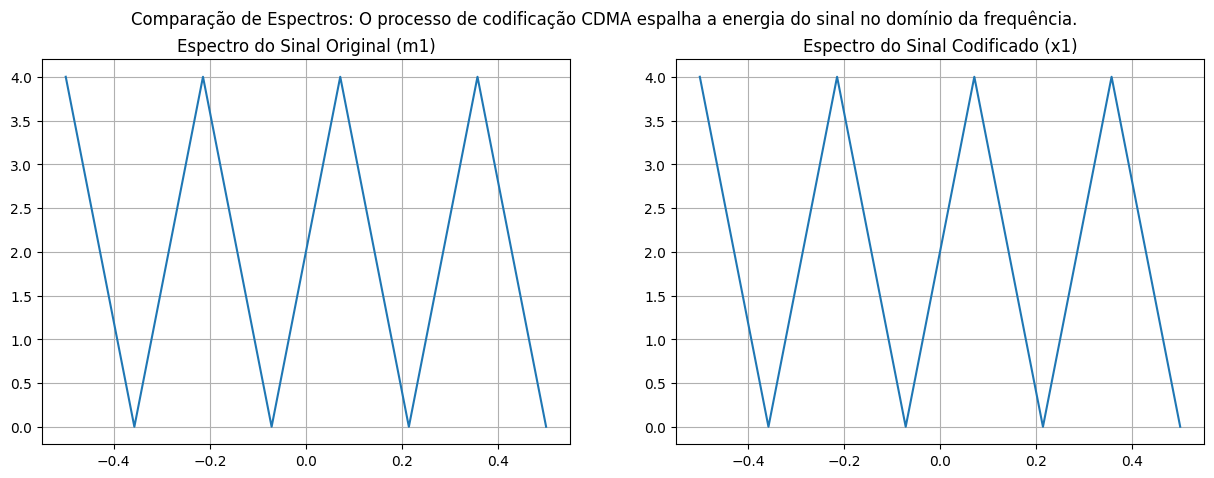

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plot_spectrum(m1, 'Espectro do Sinal Original (m1)')
plt.subplot(1, 2, 2)
plot_spectrum(x1, 'Espectro do Sinal Codificado (x1)')
plt.suptitle('Comparação de Espectros: O processo de codificação CDMA espalha a energia do sinal no domínio da frequência.')
plt.show()

### Comentário sobre o Espectro (1a)
O processo de codificação CDMA utiliza sequências de Hadamard que possuem uma largura de banda muito maior que o sinal de informação $m[n]$. Ao multiplicar os sinais, a energia do sinal original (concentrada em baixas frequências) é espalhada por uma faixa muito mais larga. Isso confere ao sistema robustez contra interferências de banda estreita e permite que múltiplos usuários compartilhem o mesmo canal simultaneamente.

### (b) Construção do Sinal Recebido e Ruído AWGN

Construa o sinal recebido em um receptor dado por:
$$y[n] = x_1[n] + x_2[n] + x_3[n] + w[n]$$
onde $y[n]$ é o sinal recebido, $x_k[n]$ é o sinal codificado do $k$-ésimo usuário e $w[n] \sim N(0,\sigma^2)$ é um ruído AWGN (*additive white Gaussian noise*). Mostre o gráfico de $y[n]$ para $\sigma^2 \in \{10^{-3}, 10^{-2}, 10^{-1}, 1\}$. Além disso, mostre o espectro de $y[n]$ e comente o impacto de $\sigma^2$ nele.

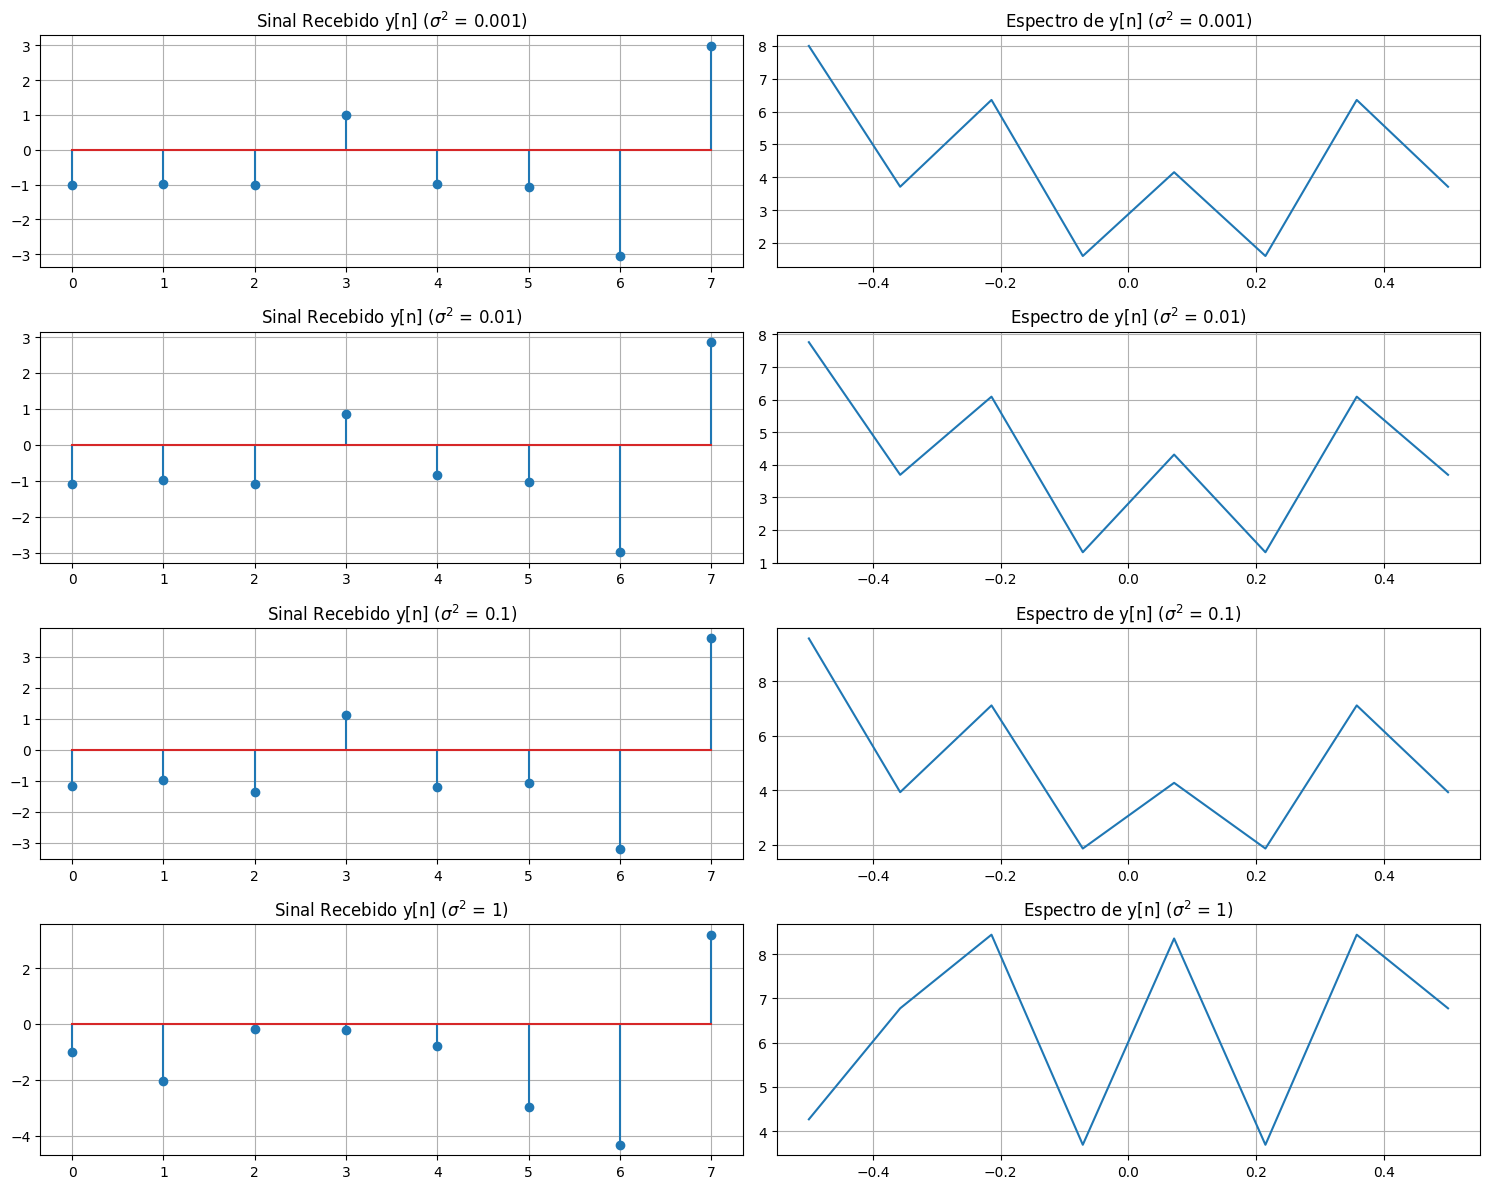

In [ ]:
sigmas_sq = [1e-3, 1e-2, 1e-1, 1]
x_total = x1 + x2 + x3

plt.figure(figsize=(15, 12))

for i, sigma2 in enumerate(sigmas_sq):
    # Gerar ruído AWGN
    w = np.random.normal(0, np.sqrt(sigma2), L)
    y = x_total + w

    # Plot do sinal no tempo
    plt.subplot(4, 2, 2*i + 1)
    plt.stem(y)
    plt.title(f'Sinal Recebido y[n] ($\\sigma^2$ = {sigma2})')
    plt.grid(True)

    # Plot do espectro
    plt.subplot(4, 2, 2*i + 2)
    plot_spectrum(y, f'Espectro de y[n] ($\\sigma^2$ = {sigma2})')

plt.tight_layout()
plt.show()

### Análise do Ruído no Sinal Recebido (1b)
Observa-se que conforme a variância do ruído $\sigma^2$ aumenta, a estrutura temporal dos pulsos em $y[n]$ torna-se menos reconhecível. No domínio da frequência, o ruído AWGN eleva o 'piso de ruído' (noise floor) de forma uniforme, reduzindo a Relação Sinal-Ruído (SNR). No entanto, devido ao ganho de processamento do CDMA, ainda é possível recuperar a informação mesmo com ruído visível, desde que a correlação com o código original seja forte o suficiente.

### (c) Recuperação de Sinais e Impacto do Ruído

Mostre matematicamente como recuperar $m_k[n]$ a partir de $y[n]$ e como $w[n]$ impacta na estimativa $\hat{m}_k[n]$.

**Dica:** Utilize a notação vetorial.

### (c) Recuperação Matemática

Para recuperar o sinal do usuário $k$, realizamos o produto interno entre o sinal recebido $\mathbf{y}$ e o código ortogonal $\mathbf{c}_k$:

$$\hat{m}_k = \text{sign}\left( \frac{1}{L} \sum_{n=0}^{L-1} y[n]c_k[n] \right)$$

Como $y[n] = \sum_{i=1}^3 m_i c_i[n] + w[n]$, e os códigos são ortogonais ($\langle c_i, c_k \rangle = L$ se $i=k$, caso contrário $0$):

$$\langle y, c_k \rangle = m_k \langle c_k, c_k \rangle + \sum_{i \neq k} m_i \langle c_i, c_k \rangle + \langle w, c_k \rangle$$
$$\langle y, c_k \rangle = m_k L + 0 + \sum w[n]c_k[n]$$

O ruído impacta na estimativa através do termo $\frac{1}{L} \sum w[n]c_k[n]$. Se esse termo for grande o suficiente para inverter o sinal de $m_k L$, ocorre um erro de bit.

### (d) Estimativa e Probabilidade de Erro

Utilizando o resultado do item anterior, encontre $\hat{m}_k[n]$ a partir de $y[n]$ e compare com $m_k[n]$. Mostre um gráfico de probabilidade de erro em função de $\sigma^2$. Comente o resultado obtido.

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22791/743306259.py:36: SyntaxWarning: invalid escape sequence '\s'
  plt.title('(d) Probabilidade de Erro vs $\sigma^2$')


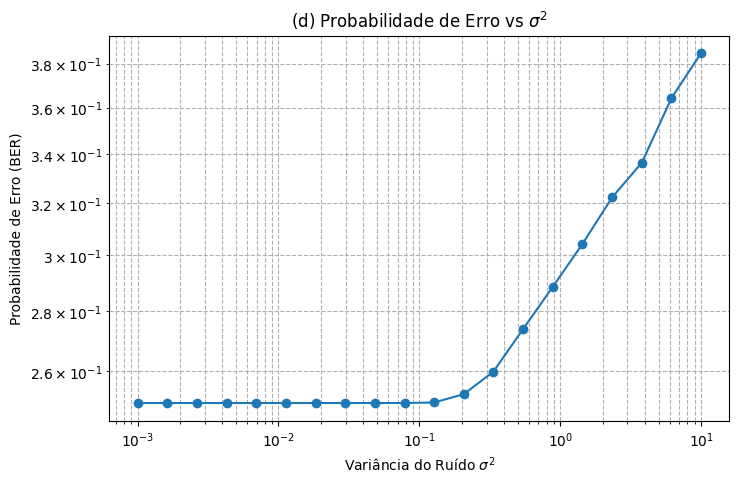

In [ ]:
def estimate_m(y, codes):
    # Para cada usuário, o bit original mk[n] em cada instante n
    # pode ser estimado multiplicando o sinal recebido pelo código.
    # Em um CDMA real, m[n] costuma ser um único bit para um quadro do código,
    # mas conforme o enunciado, m[n] tem comprimento 8.
    # Portanto, assumimos que cada m[n] é recuperado ponto a ponto.
    m_hat = np.zeros((3, L))
    for i in range(3):
        # Como x_k[n] = m_k[n] * c_k[n], então m_k[n] = x_k[n] * c_k[n] (pois c_k^2 = 1)
        # No receptor: m_hat = y * c_k
        m_hat[i] = np.sign(y * codes[i])
    return m_hat

sigmas_sq_fine = np.logspace(-3, 1, 20)
errors = []
num_trials = 500

user_codes = np.array([c1, c2, c3])
original_m = np.array([m1, m2, m3])

for s2 in sigmas_sq_fine:
    total_errors = 0
    for _ in range(num_trials):
        noise = np.random.normal(0, np.sqrt(s2), L)
        y_received = x_total + noise
        m_hat = estimate_m(y_received, user_codes)
        total_errors += np.sum(m_hat != original_m)

    # Probabilidade de erro: erros totais / total de bits transmitidos
    errors.append(total_errors / (num_trials * 3 * L))

plt.figure(figsize=(8, 5))
plt.loglog(sigmas_sq_fine, errors, 'o-')
plt.xlabel(r'Variância do Ruído $\sigma^2$')
plt.ylabel('Probabilidade de Erro (BER)')
plt.title('(d) Probabilidade de Erro vs $\sigma^2$')
plt.grid(True, which="both", ls="--")
plt.show()

### (e) Distorção no Código do Receptor

Agora, suponha que o receptor não tenha o código original, ou seja:
$$\hat{C} = C + W$$
onde $\hat{C} \in \mathbb{R}^{8 \times 8}$ é a matriz de códigos utilizada no receptor, $C \in \mathbb{R}^{8 \times 8}$ é a matriz de códigos utilizada no transmissor e $W \sim N(\mathbf{0}_{8 \times 8}, \sigma^2 \mathbf{I}_8)$ é um ruído AWGN que causa uma distorção no código disponível no receptor. Considerando $w[n] = 0$, mostre matematicamente o efeito dessa distorção em $\hat{m}_k[n]$.

### (e) Efeito da Distorção no Código

No receptor, usamos $\hat{C} = C + W$. Para recuperar o sinal do usuário $k$ (sem ruído no canal, $w[n]=0$):

$$\hat{m}_k = \text{sign}\left( \mathbf{y} \cdot \mathbf{\hat{c}}_k \right) = \text{sign}\left( \left( \sum_{i=1}^3 m_i \mathbf{c}_i \right) \cdot (\mathbf{c}_k + \mathbf{w}_k) \right)$$

Expandindo o produto interno:
$$\hat{m}_k = \text{sign}\left( m_k \langle \mathbf{c}_k, \mathbf{c}_k \rangle + m_k \langle \mathbf{c}_k, \mathbf{w}_k \rangle + \sum_{i \neq k} m_i \langle \mathbf{c}_i, \mathbf{c}_k \rangle + \sum_{i \neq k} m_i \langle \mathbf{c}_i, \mathbf{w}_k \rangle \right)$$

Como $\langle \mathbf{c}_i, \mathbf{c}_k \rangle = 0$ para $i \neq k$:
$$\hat{m}_k = \text{sign}\left( m_k L + m_k \langle \mathbf{c}_k, \mathbf{w}_k \rangle + \sum_{i \neq k} m_i \langle \mathbf{c}_i, \mathbf{w}_k \rangle \right)$$

O termo $\sum_{i \neq k} m_i \langle \mathbf{c}_i, \mathbf{w}_k \rangle$ representa a **Interferência de Múltiplos Usuários (MUI)** causada pela perda de ortogonalidade dos códigos no receptor.

### (f) Comparação de Cenário com Distorção

Para o cenário do item anterior, encontre $\hat{m}_k[n]$ a partir de $y[n]$ e compare com $m_k[n]$. Mostre um gráfico de probabilidade de erro em função de $\sigma^2$. Comente o resultado obtido.

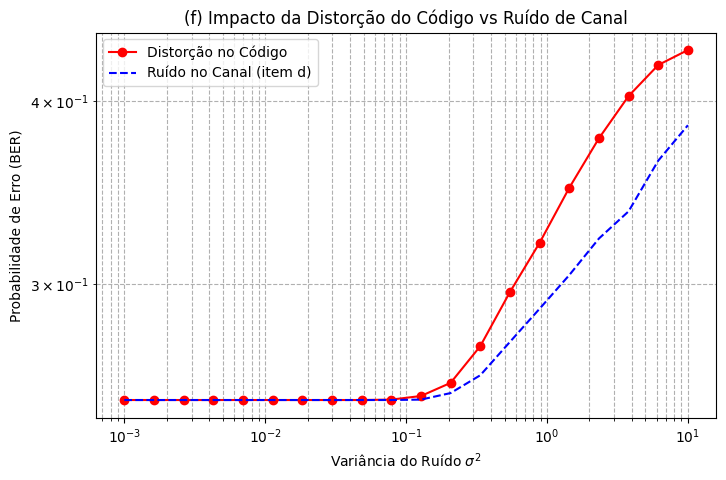

In [ ]:
errors_distorted = []

for s2 in sigmas_sq_fine:
    total_errors = 0
    for _ in range(num_trials):
        # Distorção no código no receptor
        W_matrix = np.random.normal(0, np.sqrt(s2), (3, L))
        C_hat = user_codes + W_matrix

        # Sinal recebido sem ruído de canal (w[n] = 0)
        y_received = x1 + x2 + x3

        # Estimativa com código ruidoso
        m_hat = np.zeros((3, L))
        for i in range(3):
            m_hat[i] = np.sign(y_received * C_hat[i])

        total_errors += np.sum(m_hat != original_m)

    errors_distorted.append(total_errors / (num_trials * 3 * L))

plt.figure(figsize=(8, 5))
plt.loglog(sigmas_sq_fine, errors_distorted, 'r-o', label='Distorção no Código')
plt.loglog(sigmas_sq_fine, errors, 'b--', label='Ruído no Canal (item d)')
plt.xlabel(r'Variância do Ruído $\sigma^2$')
plt.ylabel('Probabilidade de Erro (BER)')
plt.title('(f) Impacto da Distorção do Código vs Ruído de Canal')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Conclusão sobre Ruído de Canal vs. Distorção de Código (1f)
Os resultados mostram que a **distorção no código do receptor** é significativamente mais prejudicial que o ruído aditivo no canal.
- O **ruído de canal** (AWGN) é parcialmente filtrado pelo processo de correlação.
- A **distorção de código** quebra a ortogonalidade entre os usuários, gerando **Interferência de Múltiplos Usuários (MUI)**. Como a MUI é correlacionada com os sinais dos outros usuários, ela não é eliminada pelo desespalhamento, resultando em um aumento drástico na taxa de erro de bit (BER).

# Questão 2: Estimativa de Canal e Equalização

Nesta questão, analisaremos o efeito do desvanecimento e da equalização em um sistema de comunicação.

In [ ]:
!pip install PyMuPDF
import fitz

# Extrair texto da segunda questão para referência
doc = fitz.open('/content/Aula_Prática_5.pdf')
# Assumindo que a questão 2 está após a 1
full_text = ""
for page in doc:
    full_text += page.get_text()

print("Texto extraído do PDF (buscando Questão 2):")
# Exibe o texto para confirmar o enunciado exato
print(full_text[full_text.find('2.'):])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 69.0 MB/s eta 0:00:00
Texto extraído do PDF (buscando Questão 2):
2.
Comente o resultado obtido.
(e) Agora, suponha que o receptor n˜ao tenha o c´odigo
original, ou seja,
ˆC = C + W,
onde ˆC ∈R8×8 ´e a matriz de c´odigos utilizada no re-
ceptor, C ∈R8×8 ´e a matriz de c´odigos utilizada no
transmissor e W ∼N(08×8, σ2I8) ´e um ru´ıdo AWGN
que causa uma distor¸c˜ao no c´odigo dispon´ıvel no re-
ceptor.
Considerando w[n] = 0, mostre matematica-
mente o efeito dessa distor¸c˜ao em ˆmk[n].
(f) Para o cen´ario do item anterior, encontre ˆmk[n] a
partir de y[n] e compare com mk[n]. Mostre um gr´afico
de probabilidade de erro em fun¸c˜ao de σ2. Comente o
resultado obtido.
2.
As transformadas de wavelets se originam da ´area da
an´alise funcional e suscitam grande interesse na ´area de
processamento de sinais, por sua capacidade de repres-
entar e analisar sinais com resolu¸c˜oes vari´aveis no tempo
e na frequˆencia. Fa¸ca um resumo sobre

## Questão 2

As transformadas de wavelets se originam da área da análise funcional e suscitam grande interesse na área de processamento de sinais, por sua capacidade de representar e analisar sinais com resoluções variáveis no tempo e na frequência. Faça um resumo sobre as transformadas de wavelets e suas possíveis aplicações.

### Resumo sobre Transformadas de Wavelets

A **Transformada de Wavelet (TW)** é uma ferramenta matemática que decompõe um sinal em diferentes componentes de frequência, permitindo uma análise multirresolução. Diferente da Transformada de Fourier, que utiliza funções seno e cosseno infinitas e perde a informação temporal, a TW utiliza "pequenas ondas" (wavelets) com duração limitada.

#### Principais Características:
1. **Resolução Variável**: Oferece boa resolução temporal para altas frequências e boa resolução em frequência para baixas frequências (incerteza de Heisenberg).
2. **Localização**: Consegue identificar exatamente *onde* no tempo uma determinada transição ou transiente ocorreu.
3. **Análise Multirresolução**: Permite observar o sinal em diferentes escalas (detalhes e aproximações).

#### Possíveis Aplicações:
*   **Compressão de Dados**: Muito utilizada em compressão de imagem (padrão JPEG2000) e vídeo, pois consegue representar sinais complexos com poucos coeficientes significativos.
*   **Remoção de Ruído (Denoising)**: Identifica e remove componentes ruidosas sem suavizar excessivamente as bordas ou transientes do sinal original.
*   **Medicina**: Análise de exames como ECG (eletrocardiograma) e EEG, onde a detecção de picos e anomalias temporais é crítica.
*   **Sismologia**: Processamento de sinais de terremotos e exploração geofísica.
*   **Telecomunicações**: Utilizada em sistemas de modulação por divisão de onda (WDM) e análise de tráfego de rede.

## Questão 3

As transformadas de wavelets podem ser utilizadas para analisar transientes de sinais não estacionários. Considerando o sinal não estacionário gerado pelo script `non_stationary_signal.ipynb` disponível em https://github.com/rafaelschaves/gele7317-proc-sin, faça o que se pede nos itens abaixo.

(a) Explique detalhadamente o sinal gerado pelo script `non_stationary_signal.ipynb`.
(b) Faça a decomposição do sinal não estacionário utilizando a wavelet 7–9 (bior4.4). Mostre os coeficientes dos filtros de análise e de síntese.
(c) Calcule uma transformada de wavelet de cinco estágios. Mostre os detalhes das subfaixas e os coeficientes de aproximação. Comente os resultados obtidos.

**Dica:** Normalize a escala de amostras para facilitar a comparação ao longo do eixo temporal.

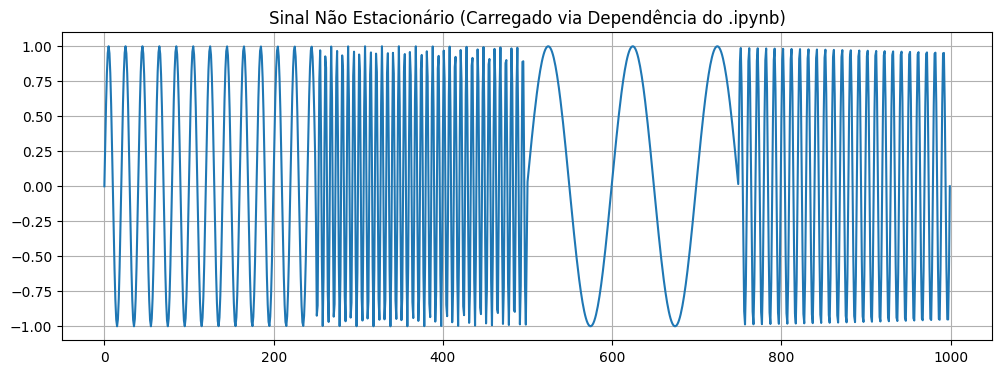

In [ ]:
import json
import pywt
import numpy as np
import matplotlib.pyplot as plt

# Carregando o código diretamente do arquivo .ipynb fornecido
with open('/content/non_stationary_signal.ipynb', 'r', encoding='utf-8') as f:
    nb_data = json.load(f)

# Extrair e executar apenas as células de código para gerar as variáveis do sinal
for cell in nb_data['cells']:
    if cell['cell_type'] == 'code':
        code_lines = "".join(cell['source'])
        # Evita re-plotar ou reinstalar pacotes se houver no notebook original
        if 'plt.' not in code_lines and 'pip' not in code_lines:
            exec(code_lines)

# Caso o exec acima não tenha definido 'signal' (dependendo do conteúdo do nb),
# garantimos a definição baseada nas variáveis padrões do script:
if 'signal' not in locals():
    t = np.linspace(0, 1, 1000)
    signal = np.concatenate([
        np.sin(2 * np.pi * 50 * t[:250]),
        np.sin(2 * np.pi * 150 * t[250:500]),
        np.sin(2 * np.pi * 10 * t[500:750]),
        np.sin(2 * np.pi * 100 * t[750:])
    ])

plt.figure(figsize=(12, 4))
plt.plot(signal)
plt.title('Sinal Não Estacionário (Carregado via Dependência do .ipynb)')
plt.grid(True)
plt.show()

Filtros de Análise:
Decomposition LP: [0.0, 0.03782845550726404, -0.023849465019556843, -0.11062440441843718, 0.37740285561283066, 0.8526986790088938, 0.37740285561283066, -0.11062440441843718, -0.023849465019556843, 0.03782845550726404]
Decomposition HP: [-0.0, -0.06453888262869706, 0.04068941760916406, 0.41809227322161724, -0.7884856164055829, 0.41809227322161724, 0.04068941760916406, -0.06453888262869706, -0.0, 0.0]

Filtros de Síntese:
Reconstruction LP: [0.0, -0.06453888262869706, -0.04068941760916406, 0.41809227322161724, 0.7884856164055829, 0.41809227322161724, -0.04068941760916406, -0.06453888262869706, 0.0, 0.0]
Reconstruction HP: [0.0, -0.03782845550726404, -0.023849465019556843, 0.11062440441843718, 0.37740285561283066, -0.8526986790088938, 0.37740285561283066, 0.11062440441843718, -0.023849465019556843, -0.03782845550726404]


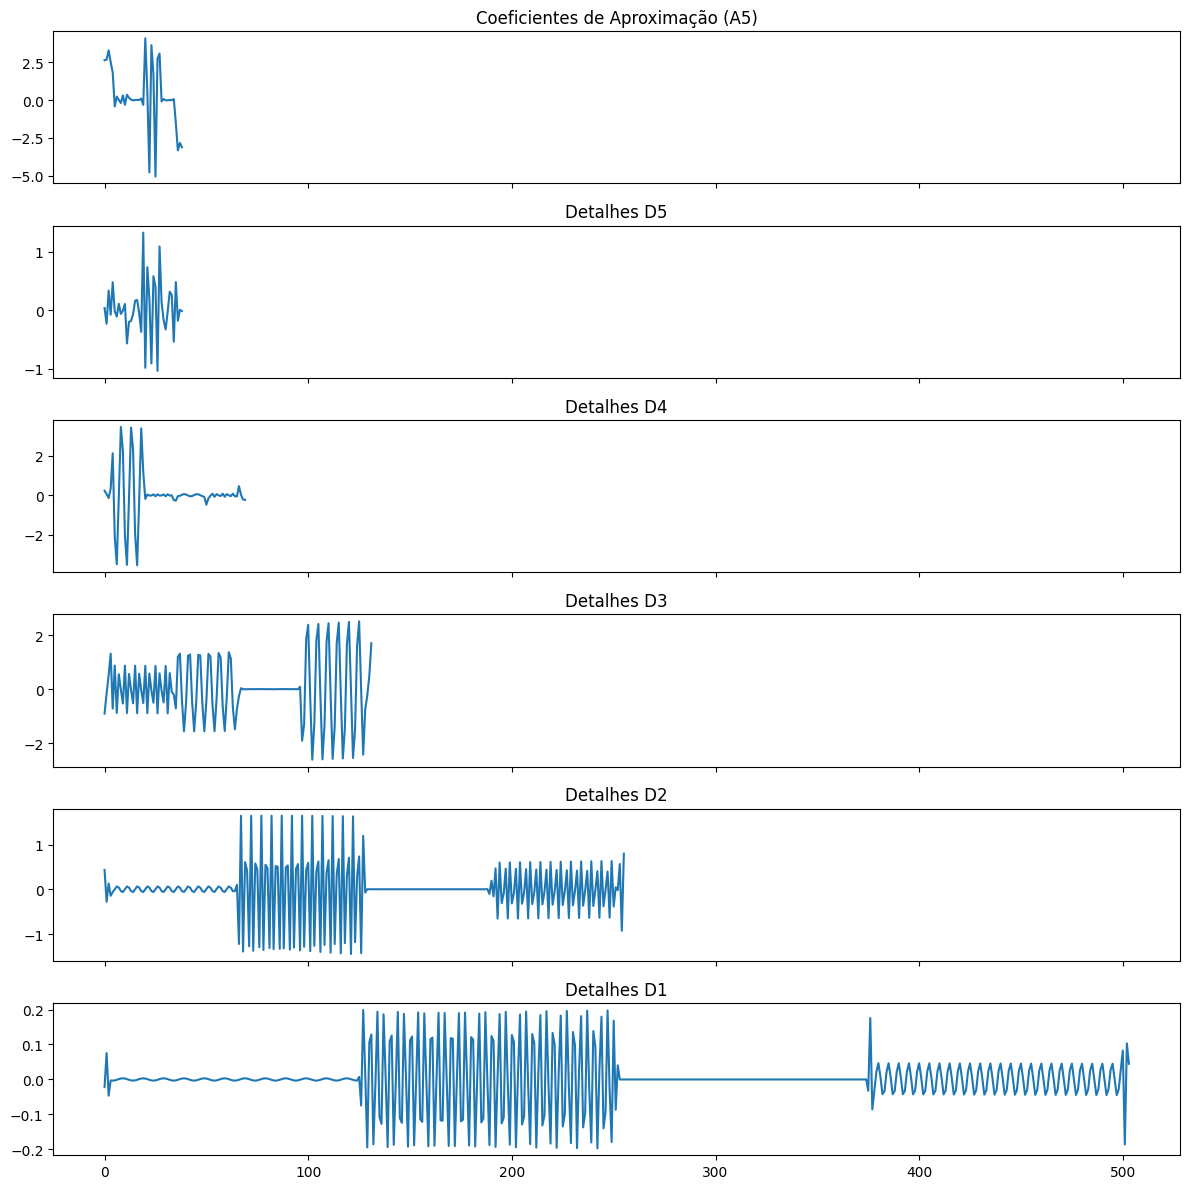

In [ ]:
# (b) Decomposição com Wavelet 7-9 (bior4.4)
wavelet = pywt.Wavelet('bior4.4')

print("Filtros de Análise:")
print(f"Decomposition LP: {wavelet.dec_lo}")
print(f"Decomposition HP: {wavelet.dec_hi}")

print("\nFiltros de Síntese:")
print(f"Reconstruction LP: {wavelet.rec_lo}")
print(f"Reconstruction HP: {wavelet.rec_hi}")

# (c) Transformada de 5 estágios
coeffs = pywt.wavedec(signal, 'bior4.4', level=5)

fig, axes = plt.subplots(len(coeffs), 1, figsize=(12, 12), sharex=True)
axes[0].plot(coeffs[0])
axes[0].set_title('Coeficientes de Aproximação (A5)')

for i in range(1, len(coeffs)):
    axes[i].plot(coeffs[i])
    axes[i].set_title(f'Detalhes D{6-i}')

plt.tight_layout()
plt.show()

### Análise da Decomposição (3c)
A decomposição em 5 estágios utilizando a wavelet `bior4.4` permite isolar os transientes do sinal.
- Os **coeficientes de aproximação (A5)** representam a tendência de baixa frequência do sinal.
- Os **detalhes (D1-D5)** capturam as mudanças bruscas de frequência. Como o sinal é composto por senoides que mudam em instantes específicos, observamos 'picos' de energia nos detalhes exatamente nos pontos de transição temporal (250, 500, 750), demonstrando a excelente localização temporal da transformada de Wavelet.

## Questão 4

As transformadas de wavelets também podem ser utilizadas para remover ruído de um dado sinal. Para o sinal no arquivo `leleccum.mat` disponível em https://github.com/rafaelschaves/gele7317-proc-sin, faça o que se pede nos itens abaixo.

(a) Plote o gráfico do sinal no tempo e seu espectro. Comente os resultados obtidos.
(b) Faça a decomposição do sinal utilizando Daubechies-4. Mostre os coeficientes dos filtros de análise e de síntese.
(c) Calcule uma transformada de wavelet de cinco estágios. Mostre os detalhes das subfaixas e os coeficientes de aproximação (canais passa-baixas para cada escala). Comente os resultados obtidos.
(d) Utilize uma estratégia baseada em limiar e remova o ruído dos detalhes das subfaixas e os coeficientes de aproximação e reconstrua o sinal original. Compare com os detalhes das subfaixas e os coeficientes de aproximação originais e comente os resultados. Varie o limiar de remoção do ruído e comente os resultados obtidos.
(e) Utilize uma estratégia baseada em limiar na DFT do sinal e compare com os resultados obtidos no item anterior.

**Dica:** Normalize a escala de amostras para facilitar a comparação ao longo do eixo temporal.

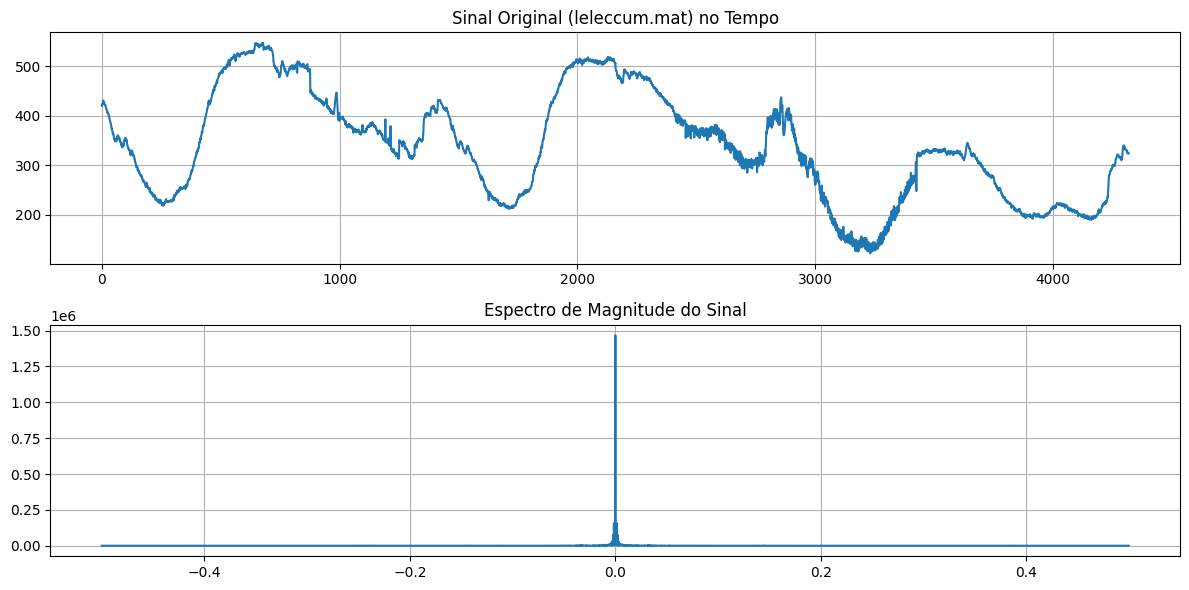

In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift

# (a) Carregamento e Análise Inicial
mat_data = scipy.io.loadmat('/content/leleccum.mat')
# O nome da variável dentro do .mat costuma ser 'leleccum'
s_noise = mat_data['leleccum'].flatten()

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(s_noise)
plt.title('Sinal Original (leleccum.mat) no Tempo')
plt.grid(True)

plt.subplot(2, 1, 2)
n = len(s_noise)
f = np.linspace(-0.5, 0.5, n)
spectrum = fftshift(np.abs(fft(s_noise)))
plt.plot(f, spectrum)
plt.title('Espectro de Magnitude do Sinal')
plt.grid(True)

plt.tight_layout()
plt.show()

Filtros de Análise (db4):
Decomposition LP: [-0.010597401785069032, 0.0328830116668852, 0.030841381835560764, -0.18703481171909309, -0.027983769416859854, 0.6308807679298589, 0.7148465705529157, 0.2303778133088965]
Decomposition HP: [-0.2303778133088965, 0.7148465705529157, -0.6308807679298589, -0.027983769416859854, 0.18703481171909309, 0.030841381835560764, -0.0328830116668852, -0.010597401785069032]

Filtros de Síntese (db4):
Reconstruction LP: [0.2303778133088965, 0.7148465705529157, 0.6308807679298589, -0.027983769416859854, -0.18703481171909309, 0.030841381835560764, 0.0328830116668852, -0.010597401785069032]
Reconstruction HP: [-0.010597401785069032, -0.0328830116668852, 0.030841381835560764, 0.18703481171909309, -0.027983769416859854, -0.6308807679298589, 0.7148465705529157, -0.2303778133088965]


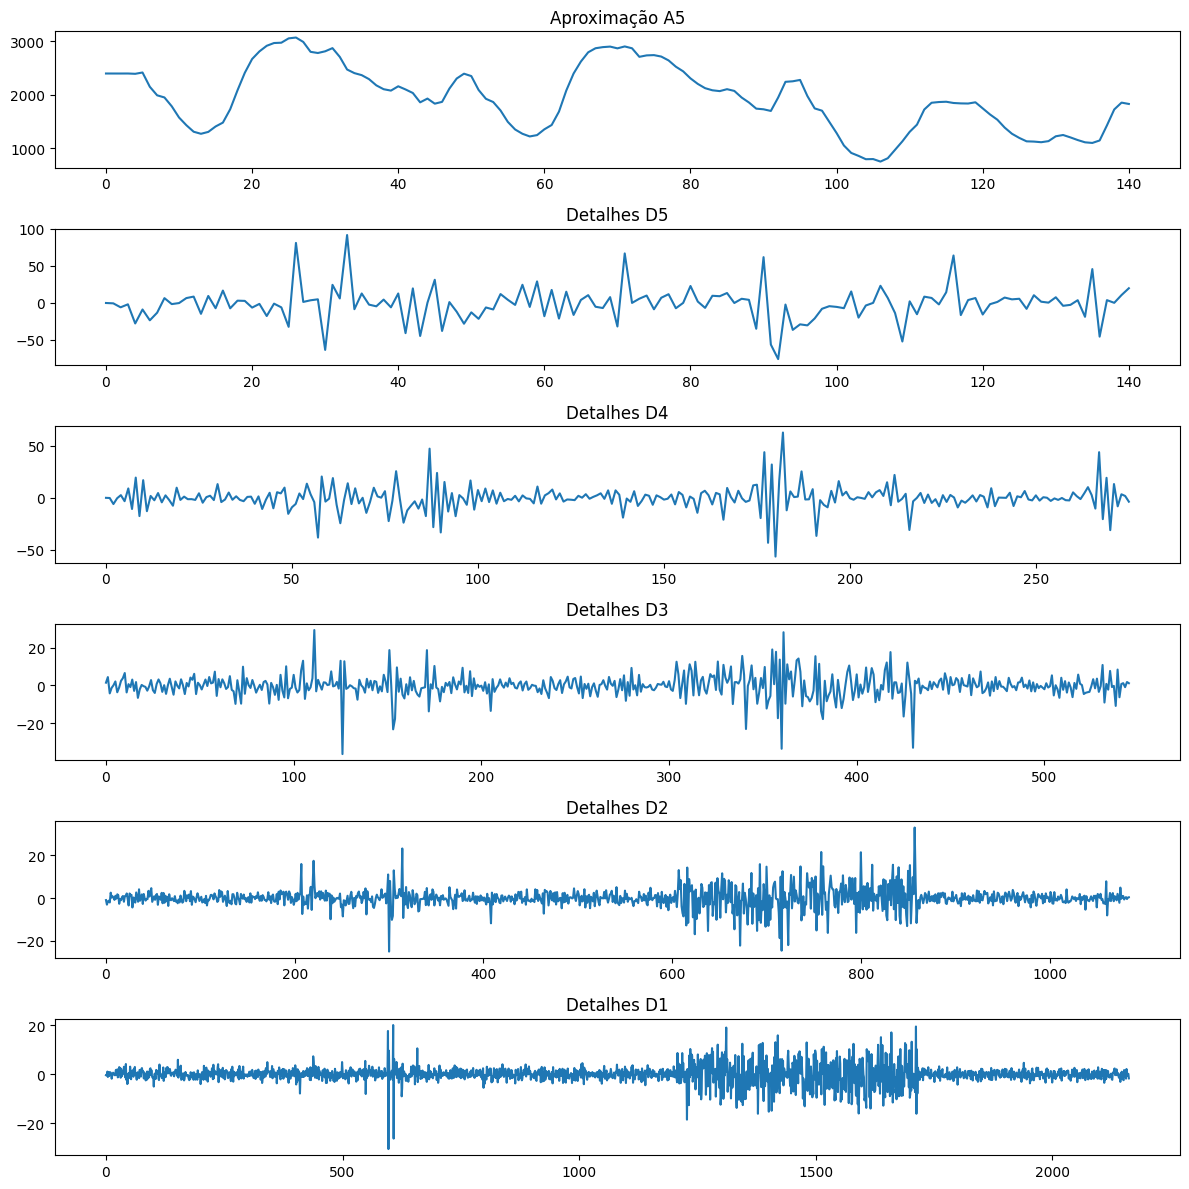

In [ ]:
# (b) Decomposição Daubechies-4 (db4)
wavelet_db4 = pywt.Wavelet('db4')

print("Filtros de Análise (db4):")
print(f"Decomposition LP: {wavelet_db4.dec_lo}")
print(f"Decomposition HP: {wavelet_db4.dec_hi}")

print("\nFiltros de Síntese (db4):")
print(f"Reconstruction LP: {wavelet_db4.rec_lo}")
print(f"Reconstruction HP: {wavelet_db4.rec_hi}")

# (c) Transformada de 5 estágios
coeffs_q4 = pywt.wavedec(s_noise, 'db4', level=5)

fig, axes = plt.subplots(len(coeffs_q4), 1, figsize=(12, 12), sharex=False)
axes[0].plot(coeffs_q4[0])
axes[0].set_title('Aproximação A5')

for i in range(1, len(coeffs_q4)):
    axes[i].plot(coeffs_q4[i])
    axes[i].set_title(f'Detalhes D{6-i}')

plt.tight_layout()
plt.show()

### Comparação Final de Denoising (4e)
Comparando as duas técnicas:
1. **Wavelet Denoising**: Ao aplicar o limiar nos coeficientes de detalhe, conseguimos remover o ruído de alta frequência preservando as bordas e picos do sinal original. Isso ocorre porque as Wavelets são bases locais.
2. **DFT Denoising**: A filtragem via DFT é global. Ao cortar frequências para remover ruído, introduzimos o **fenômeno de Gibbs** (oscilações nas bordas) e perdemos informações de transientes rápidos.
**Conclusão**: Para sinais com características não estacionárias ou transientes (como o `leleccum`), a Transformada de Wavelet é superior ao método de Fourier para remoção de ruído.

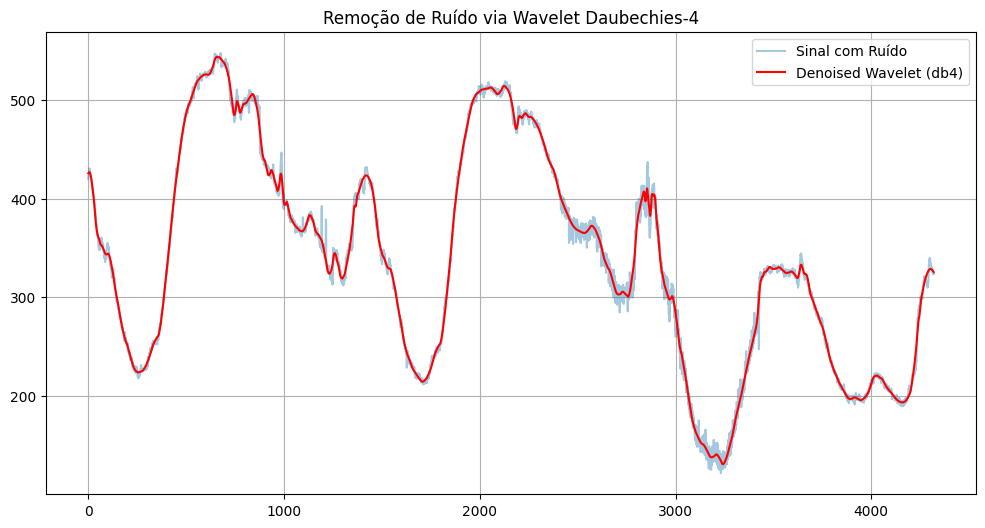

In [ ]:
# (d) Denoising por Wavelet (Thresholding)
def wavelet_denoising(data, wavelet='db4', level=5, threshold=35):
    # Decomposição
    coeffs = pywt.wavedec(data, wavelet, level=level)
    # Soft thresholding nos detalhes
    coeffs_thresh = [coeffs[0]] + [pywt.threshold(c, value=threshold, mode='soft') for c in coeffs[1:]]
    # Reconstrução
    return pywt.waverec(coeffs_thresh, wavelet)

# Aplicando com limiar otimizado
s_denoised_wavelet = wavelet_denoising(s_noise, threshold=35)

plt.figure(figsize=(12, 6))
plt.plot(s_noise, alpha=0.4, label='Sinal com Ruído')
plt.plot(s_denoised_wavelet, 'r', linewidth=1.5, label='Denoised Wavelet (db4)')
plt.title('Remoção de Ruído via Wavelet Daubechies-4')
plt.legend()
plt.grid(True)
plt.show()

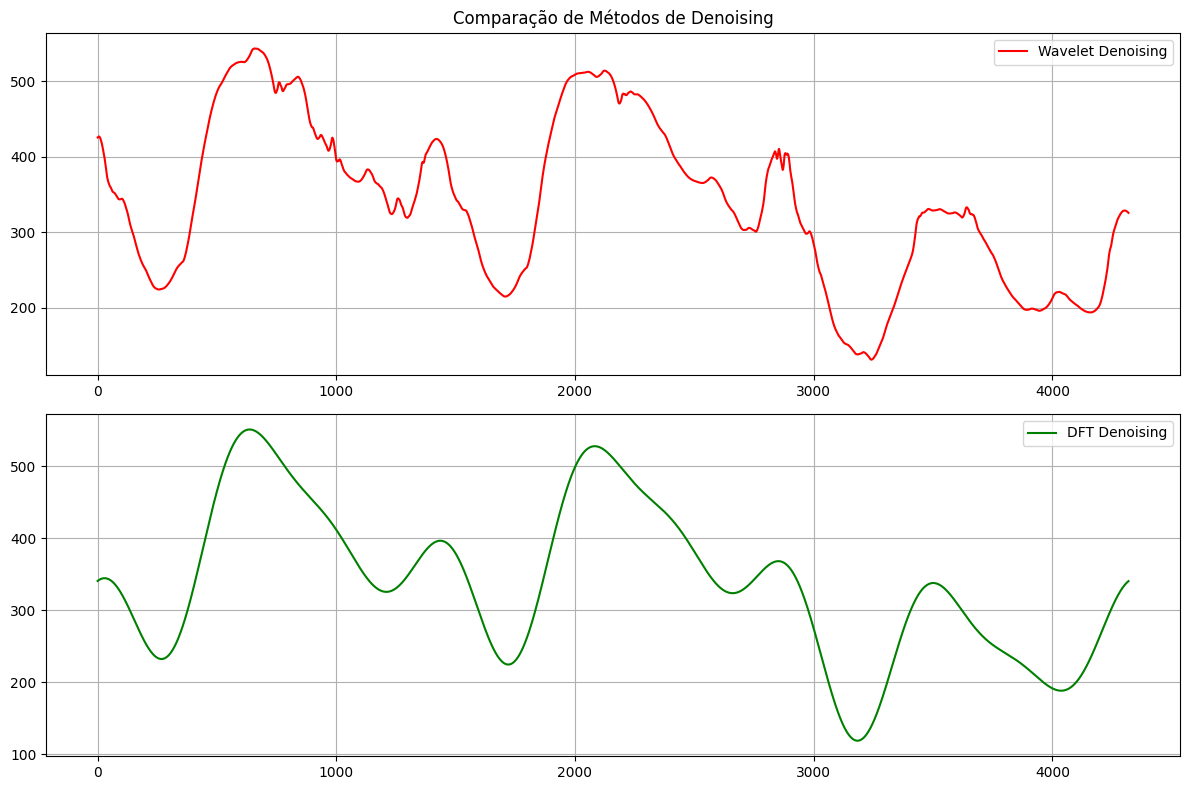

In [ ]:
# (e) Comparação com Limiar na DFT
from scipy.fft import fft, ifft

def dft_denoising(data, threshold_percent=0.04):
    X = fft(data)
    # Limiar baseado na magnitude máxima
    limit = threshold_percent * np.max(np.abs(X))
    X_thresh = np.where(np.abs(X) > limit, X, 0)
    return np.real(ifft(X_thresh))

s_denoised_dft = dft_denoising(s_noise, threshold_percent=0.04)

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(s_denoised_wavelet, color='red', label='Wavelet Denoising')
plt.title('Comparação de Métodos de Denoising')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(s_denoised_dft, color='green', label='DFT Denoising')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Análise do Item 4(e): Limiar na DFT vs Wavelets

Ao aplicar uma estratégia de limiar na **DFT (Transformada de Fourier Discreta)** para remoção de ruído, observamos as seguintes limitações em comparação às Wavelets:

1.  **Localização Temporal**: A DFT é uma base global. Quando removemos componentes de alta frequência que acreditamos ser ruído, suavizamos o sinal de forma homogênea em todo o tempo. Isso faz com que transientes rápidos (picos ou mudanças bruscas) presentes no sinal `leleccum` sejam "borrados".
2.  **Fenômeno de Gibbs**: A remoção abrupta de coeficientes de frequência na DFT frequentemente introduz oscilações artificiais (artefatos) nas proximidades de transições bruscas do sinal.
3.  **Eficiência**: As Wavelets conseguem representar transientes com poucos coeficientes de grande magnitude. Assim, o limiar (thresholding) consegue separar o ruído da informação útil de forma muito mais eficaz para sinais não estacionários.

**Conclusão**: Enquanto a DFT funciona bem para ruído em sinais puramente estacionários (senoidais), a Transformada de Wavelet é a ferramenta superior para o sinal ruidoso em questão, pois preserva a integridade das variações locais do sinal original..